## Section B: Answers

1. Mean = 6.43, Median = 6, Range = 7, Sample Variance = 6.95, Sample Std = 2.64
2. P(both red) = 3/5 x 2/4 = 0.3
3. P(disease | positive) = (0.99 x 0.01) / 0.0594 = 0.1667 (16.7%)
4. P(marks > 85) = 0.0668 (Z = 1.5). 90th percentile = 70 + 1.2816 x 10 = 82.82
5. P(X = 2) = (4^2 x e^-4) / 2! = 0.1465
6. P(X = 6) = C(10,6) x 0.5^10 = 210 / 1024 = 0.2051
7. Z = (32 - 30) / (6 / 6) = 2.0, two-tailed p = 0.0455 (reject H0)
8. Covariance = 50, Pearson r = 50 / (3.162 x 15.969) = 0.990

In [3]:
# Exercise 1
import numpy as np
import statistics

data = [4, 8, 6, 5, 3, 9, 10, 6]

n = len(data)
mean = sum(data) / n
s = sorted(data)
median = (s[n // 2 - 1] + s[n // 2]) / 2 if n % 2 == 0 else s[n // 2]
mode = max(set(data), key=data.count)
variance = sum((x - mean) ** 2 for x in data) / (n - 1)
std = variance ** 0.5

print("Manual  -> Mean:", mean, "| Median:", median, "| Mode:", mode,
      "| Variance:", round(variance, 3), "| Std:", round(std, 3))

print("NumPy   -> Mean:", np.mean(data), "| Median:", np.median(data),
      "| Mode:", statistics.mode(data),
      "| Variance:", round(np.var(data, ddof=1), 3), "| Std:", round(np.std(data, ddof=1), 3))

Manual  -> Mean: 6.375 | Median: 6.0 | Mode: 6 | Variance: 5.982 | Std: 2.446
NumPy   -> Mean: 6.375 | Median: 6.0 | Mode: 6 | Variance: 5.982 | Std: 2.446


In [4]:
# Exercise 2
values = [2, 4, 4, 4, 5, 5, 7, 9]

def variances(data):
    n = len(data)
    mean = sum(data) / n
    ss = sum((x - mean) ** 2 for x in data)
    return ss / n, ss / (n - 1)

pop_var, samp_var = variances(values)
print("Population variance:", pop_var)
print("Sample variance:", round(samp_var, 4))

Population variance: 4.0
Sample variance: 4.5714


In [5]:
# Exercise 3
import numpy as np

salaries = [25000, 28000, 30000, 32000, 35000, 38000, 40000, 45000, 200000]

q1 = np.percentile(salaries, 25)
q3 = np.percentile(salaries, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = [x for x in salaries if x < lower or x > upper]

print("Q1:", q1, "| Q3:", q3, "| IQR:", iqr)
print("Lower fence:", lower, "| Upper fence:", upper)
print("Outliers:", outliers)

Q1: 30000.0 | Q3: 40000.0 | IQR: 10000.0
Lower fence: 15000.0 | Upper fence: 55000.0
Outliers: [200000]


In [6]:
# Exercise 4
import numpy as np

marks = [55, 58, 60, 62, 65, 61, 59, 63, 97]
arr = np.array(marks, dtype=float)

z = (arr - arr.mean()) / arr.std()
outliers = arr[np.abs(z) > 2.5]

print("Z-scores:", np.round(z, 2))
print("Outliers:", outliers)

Z-scores: [-0.8  -0.54 -0.38 -0.21  0.05 -0.29 -0.46 -0.12  2.75]
Outliers: [97.]


Pearson: 0.9851
Spearman: 1.0
Covariance: 63.0


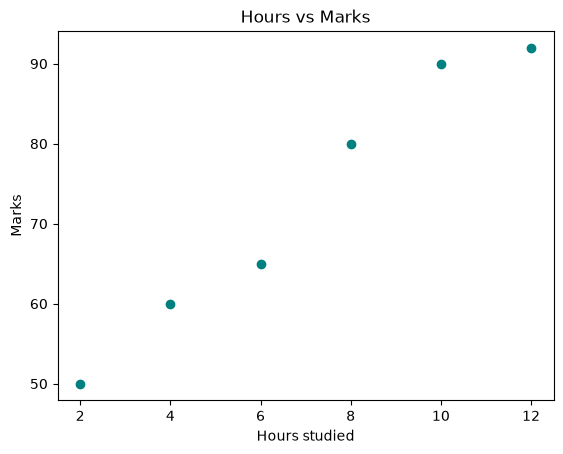

In [7]:
# Exercise 5
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

hours = [2, 4, 6, 8, 10, 12]
marks = [50, 60, 65, 80, 90, 92]

pearson_r, p1 = stats.pearsonr(hours, marks)
spearman_r, p2 = stats.spearmanr(hours, marks)
cov = np.cov(hours, marks)[0, 1]

print("Pearson:", round(pearson_r, 4))
print("Spearman:", round(spearman_r, 4))
print("Covariance:", round(cov, 2))

plt.scatter(hours, marks, color="teal")
plt.title("Hours vs Marks")
plt.xlabel("Hours studied")
plt.ylabel("Marks")
plt.show()

In [8]:
# Exercise 6
import numpy as np

p_disease = 0.01
p_pos_given_disease = 0.99
p_pos_given_healthy = 0.05

p_pos = p_pos_given_disease * p_disease + p_pos_given_healthy * (1 - p_disease)
posterior = p_pos_given_disease * p_disease / p_pos
print("P(disease | positive):", round(posterior, 4))

np.random.seed(42)
n = 1_000_000
sick = np.random.rand(n) < p_disease
test_pos = np.where(sick,
                    np.random.rand(n) < p_pos_given_disease,
                    np.random.rand(n) < p_pos_given_healthy)
print("Simulated:", round(sick[test_pos].mean(), 4))

P(disease | positive): 0.1667
Simulated: 0.1663


In [9]:
# Exercise 7
import numpy as np
from scipy import stats

group_a = [72, 75, 78, 80, 69, 74, 77, 71, 76, 73]
group_b = [80, 85, 88, 90, 79, 84, 87, 82, 86, 83]
alpha = 0.05

p_a = stats.shapiro(group_a).pvalue
p_b = stats.shapiro(group_b).pvalue
print("Shapiro p-values:", round(p_a, 3), round(p_b, 3))

if p_a > alpha and p_b > alpha:
    test = "Welch t-test"
    p = stats.ttest_ind(group_a, group_b, equal_var=False).pvalue
else:
    test = "Mann-Whitney U"
    p = stats.mannwhitneyu(group_a, group_b, alternative="two-sided").pvalue

print("Test used:", test)
print("p-value:", round(p, 6))
print("Decision:", "Reject H0" if p < alpha else "Fail to reject H0")

Shapiro p-values: 1.0 0.983
Test used: Welch t-test
p-value: 5e-06
Decision: Reject H0


Mean: 9.73 | Median: 6.87
Skewness: 1.87


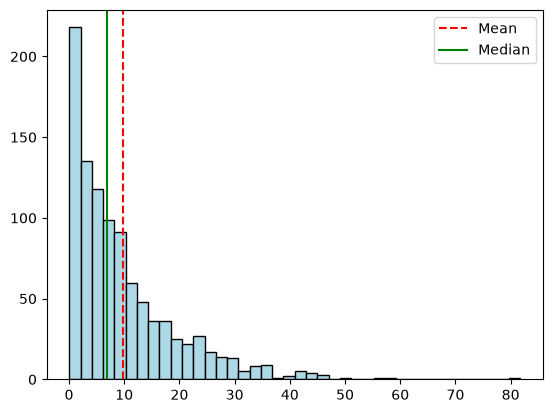

Skewness after log: -0.83


In [10]:
# Exercise 8
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
data = np.random.exponential(scale=10, size=1000)

print("Mean:", round(data.mean(), 2), "| Median:", round(np.median(data), 2))
print("Skewness:", round(stats.skew(data), 2))

plt.hist(data, bins=40, color="lightblue", edgecolor="black")
plt.axvline(data.mean(), color="red", linestyle="--", label="Mean")
plt.axvline(np.median(data), color="green", label="Median")
plt.legend()
plt.show()

logged = np.log(data)
print("Skewness after log:", round(stats.skew(logged), 2))

             age  experience  salary
age         1.00       -0.11   -0.00
experience -0.11        1.00   -0.05
salary     -0.00       -0.05    1.00


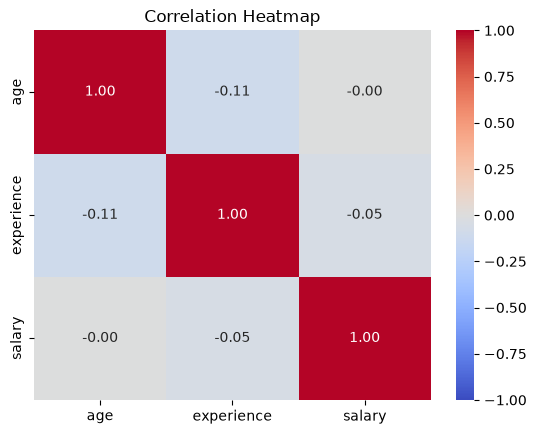

Highest pair: ('age', 'experience') | r = -0.106


In [11]:
# Exercise 9
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
df = pd.DataFrame({
    "age": np.random.randint(20, 60, 100),
    "experience": np.random.randint(0, 35, 100),
    "salary": np.random.randint(25000, 120000, 100),
})

corr = df.corr()
print(corr.round(2))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top = pairs.abs().idxmax()
print("Highest pair:", top, "| r =", round(pairs[top], 3))

In [12]:
# Exercise 10
import numpy as np
import pandas as pd

np.random.seed(42)
N = 10000
population = pd.DataFrame({
    "segment": np.random.choice(["Regular", "Premium", "VIP"], N, p=[0.6, 0.3, 0.1])
})

random_sample = population.sample(n=500, random_state=42)
stratified_sample = population.groupby("segment").sample(frac=0.05, random_state=42)

comparison = pd.DataFrame({
    "Population": population["segment"].value_counts(normalize=True),
    "Random": random_sample["segment"].value_counts(normalize=True),
    "Stratified": stratified_sample["segment"].value_counts(normalize=True),
}).round(3)
print(comparison)

         Population  Random  Stratified
segment                                
Regular       0.611   0.602       0.610
Premium       0.293   0.284       0.294
VIP           0.096   0.114       0.096
